In [13]:
# Module
from bs4 import BeautifulSoup
from selenium import webdriver
import urllib.request as req
import os
import time
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
import pandas as pd

In [6]:
def scroll_down(driver, pause_time=1.5):
    prev_height = driver.execute_script("return document.body.scrollHeight")
    while True:
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(pause_time)
        curr_height = driver.execute_script("return document.body.scrollHeight")
        if curr_height == prev_height:
            break
        prev_height = curr_height

In [7]:

# 실행
driver = webdriver.Chrome()
driver.get("https://my.homeplus.co.kr/store")

# 버튼 클릭
xpath = '//*[@id="btnSearchStoreH"]'
element = driver.find_element(By.XPATH, xpath)
actions = ActionChains(driver)
actions.move_to_element(element).perform()
time.sleep(0.5)
element.click()

# 스크롤 충분히 내리기
time.sleep(2)
scroll_down(driver, pause_time=1.5)

# 전체 페이지 파싱
html = driver.page_source
soup = BeautifulSoup(html,"html.parser")
b_list = soup.select("body > div > section > div.search-store__cont > div.searchResult > ul > li >div > a")

# 결과 추출
links = []
for b in b_list:
    link = "https://my.homeplus.co.kr/"+b.attrs['href']
    links.append(link)
    print(link)
    a = b.find("span")

driver.quit()

https://my.homeplus.co.kr//store/store_detail?storId=590
https://my.homeplus.co.kr//store/store_detail?storId=591
https://my.homeplus.co.kr//store/store_detail?storId=592
https://my.homeplus.co.kr//store/store_detail?storId=593
https://my.homeplus.co.kr//store/store_detail?storId=594
https://my.homeplus.co.kr//store/store_detail?storId=595
https://my.homeplus.co.kr//store/store_detail?storId=596
https://my.homeplus.co.kr//store/store_detail?storId=597
https://my.homeplus.co.kr//store/store_detail?storId=649
https://my.homeplus.co.kr//store/store_detail?storId=598
https://my.homeplus.co.kr//store/store_detail?storId=599
https://my.homeplus.co.kr//store/store_detail?storId=601
https://my.homeplus.co.kr//store/store_detail?storId=639
https://my.homeplus.co.kr//store/store_detail?storId=602
https://my.homeplus.co.kr//store/store_detail?storId=603
https://my.homeplus.co.kr//store/store_detail?storId=604
https://my.homeplus.co.kr//store/store_detail?storId=605
https://my.homeplus.co.kr//stor

In [9]:
store_data = []  # 매장명과 도로명주소를 저장할 리스트

for link in links:
    driver1 = webdriver.Chrome()
    driver1.get(link)
    time.sleep(2)

    html = driver1.page_source
    soup = BeautifulSoup(html, "html.parser")

    # 매장명 가져오기
    store = soup.select_one("div.hp_wrap > div.hp_top > h2")
    store_name = store.get_text(strip=True)

    # 도로명 주소 가져오기
    content = soup.select_one("div.shop_mid dl.shop_detail_01.on > dd:nth-child(10)")
    address = content.get_text(strip=True).replace("길 찾기", "")

    # 튜플로 저장
    store_data.append((store_name, address))
    print(store_name, address)

    driver1.quit()

가양점 서울특별시 강서구 양천로 431
가좌점 인천광역시 서구 가정로 151번길 11
간석점 인천광역시 남동구 경원대로 971
강동점 서울특별시 강동구 양재대로 1571(메르디안 쇼핑센터)
강릉점 강원특별자치도 강릉시 경강로 2120
강서점 서울특별시 강서구 화곡로 398
거제점 경상남도 거제시 장평로 12
경기하남점 경기도 하남시 하남대로 747
경산점 경상북도 경산시 경안로 288
경주점 경상북도 경주시 공단로 97
계룡점 충청남도 계룡시 계룡대로 304
계산점 인천광역시 계양구 오조산 공원로 14
고양터미널점 경기도 고양시 일산동구 중앙로 1036
광양점 전라남도 광양시 항만11로 70
광주하남점 광주광역시 광산구 용아로 390
구미점 경상북도 구미시 구미대로 174
구월점 인천광역시 남동구 예술로 198
금천점 서울특별시 금천구 시흥대로 391
김제점 전북특별자치도 김제시 금성로 114
김포점 경기도 김포시 중봉로 14
김포풍무점 경기도 김포시 풍무로 167
김해점 경상남도 김해시 김해대로 2078
남대구점 대구광역시 남구 대명로 116
남양주진접점 경기도 남양주시 진접읍 장현리 216-1
내당점 대구광역시 서구 달구벌대로 1821
논산점 충청남도 논산시 시민로 187
대구수성점 대구광역시 수성구 동대구로 95
대전가오점 대전광역시 동구 은어송로 72
동광주점 광주광역시 북구 동문대로 200
동대문점 서울특별시 동대문구 천호대로 133
동래점 부산광역시 동래구 중앙대로 1523
동수원점 경기도 수원시 팔달구 효원로 257
동청주점 충청북도 청주시 청원구 충청대로 114 지하1층
동촌점 대구광역시 동구 동촌로 127
마산점 경상남도 창원시 마산회원구 삼호로 56
면목점 서울시 중랑구 사가정로 332 (면목동)
목포점 전라남도 목포시 영산로 313
문경점 경상북도 문경시 모전로 65
문화점 대전광역시 중구 계백로 1690
밀양점 경상남도 밀양시 점필재로 45
방학점 서울특별시 도봉구 도봉로 678
병점점 경기도 화성시 경기대로 985
보령점 충청남도 보령시

In [ ]:
my_key ='구글 API'


In [31]:
addresses = [addr for _, addr in store_data]
store_names = [name for name, _ in store_data]

In [39]:
### Google Geocoding
#!pip install googlemaps

import googlemaps
map = googlemaps.Client(key=my_key)
lat = []
lng = []
#장소(또는 주소) 리스트
places = addresses
i =0
for place in places:
    i +=1
    try:
        print(i,place)
        geo_location= map.geocode(place)
        print(geo_location)
        lat.append(geo_location[0]['geometry']['location']['lat'])
        lng.append(geo_location[0]['geometry']['location']['lng'])

    except:
        lat.append('')
        lng.append('')
        print(i)
df = pd.DataFrame(
    {   
        "지점명" :store_names,
        "위도": lat,
        "경도": lng
    },
)

df

1 서울특별시 강서구 양천로 431
[{'address_components': [{'long_name': '431', 'short_name': '431', 'types': ['premise']}, {'long_name': 'Yangcheon-ro', 'short_name': 'Yangcheon-ro', 'types': ['political', 'sublocality', 'sublocality_level_4']}, {'long_name': 'Gangseo-gu', 'short_name': 'Gangseo-gu', 'types': ['political', 'sublocality', 'sublocality_level_1']}, {'long_name': 'Seoul', 'short_name': 'Seoul', 'types': ['administrative_area_level_1', 'political']}, {'long_name': 'South Korea', 'short_name': 'KR', 'types': ['country', 'political']}, {'long_name': '07527', 'short_name': '07527', 'types': ['postal_code']}], 'formatted_address': '431 Yangcheon-ro, Gangseo-gu, Seoul, South Korea', 'geometry': {'location': {'lat': 37.5642688, 'lng': 126.8501054}, 'location_type': 'ROOFTOP', 'viewport': {'northeast': {'lat': 37.5656177802915, 'lng': 126.8514543802915}, 'southwest': {'lat': 37.5629198197085, 'lng': 126.8487564197085}}}, 'place_id': 'ChIJOf5zsgucfDURcQ9s4GZPsz8', 'plus_code': {'compound_code':

,지점명,위도,경도
0,가양점,37.564269,126.850105
1,가좌점,37.497618,126.670731
2,간석점,37.469554,126.689014
3,강동점,37.545717,127.142251
4,강릉점,37.755701,128.898678
...,...,...,...
121,포천송우점,37.824288,127.141288
122,포항점,36.012731,129.348909
123,합정점,37.550934,126.913782
124,화성동탄점,37.202788,127.068460


In [34]:
import folium

In [40]:
df

,지점명,위도,경도
0,가양점,37.564269,126.850105
1,가좌점,37.497618,126.670731
2,간석점,37.469554,126.689014
3,강동점,37.545717,127.142251
4,강릉점,37.755701,128.898678
...,...,...,...
121,포천송우점,37.824288,127.141288
122,포항점,36.012731,129.348909
123,합정점,37.550934,126.913782
124,화성동탄점,37.202788,127.068460



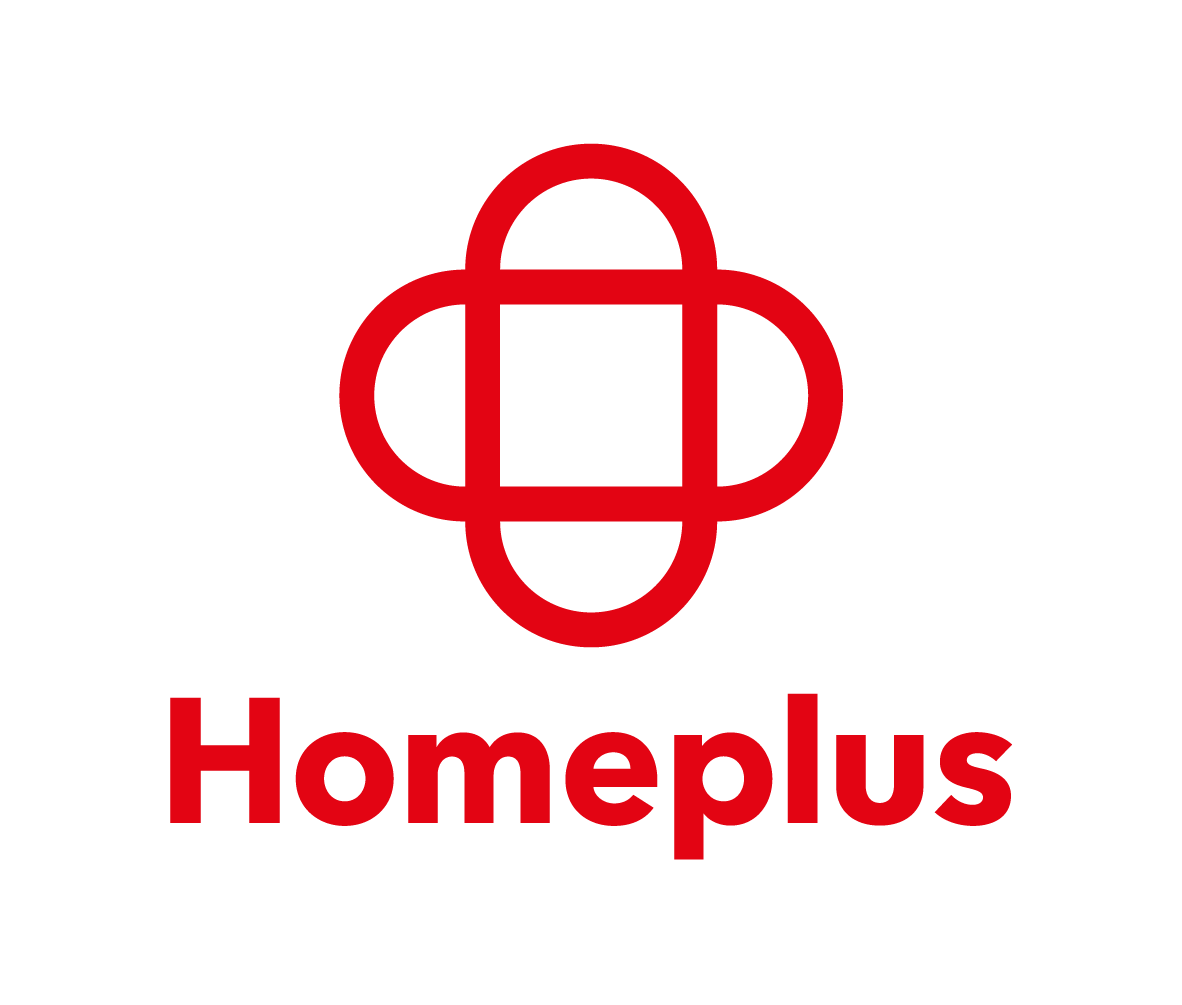

In [ ]:
#서울 지도에 학교 위치 표시
seoul_map = folium.Map(
    location=[37.55,126.98],
    zoon_start = 12
)
#이거 그거 사진 장소 
image_path = '../Data/image.png' 
custom_icon = folium.CustomIcon(
    image_path,
    icon_size=(40, 40)  # 아이콘 크기 (너비, 높이)
)
#대학교 위치 정보를 Marker로 표시
for name,lat,lng in zip(df.지점명,df.위도,df.경도):
    popup = folium.Popup(name,max_width=200)
    folium.Marker(
        [lat,lng],
        popup = popup,
        icon=custom_icon
    ).add_to(seoul_map)
    folium.CircleMarker(
        [lat,lng],
        radius = 15,
        color = 'white',#원의 둘레 색상,
        fill_color = 'white',
        fill_opacity = 0.7,
        fill=True
    ).add_to(seoul_map)

seoul_map 